# Análise Exploratória de Dados — Indicador Criança Alfabetizada (INEP)

**Tech Challenge Fase 2 — POSTECH AI Scientist**

Este notebook explora as cinco bases do projeto antes da construção da pipeline, com dois objetivos: **conhecer o comportamento do indicador** (distribuição, cobertura territorial, evolução entre anos, relação com as metas pactuadas) e **fundamentar as decisões de engenharia** adotadas nas camadas Bronze, Silver e Gold (particionamento por ano, regras de qualidade e visões analíticas).

**Fontes**: [Base dos Dados — Indicador Criança Alfabetizada](https://basedosdados.org/dataset/073a39d4-89cf-4068-b1e8-34ed0d9c0b72) (origem INEP), arquivos versionados em `../dados/`.

---

**Pergunta norteadora:** *"Quais UFs e municípios estão no caminho de atingir as metas de alfabetização pactuadas — e o que os dados exigem da pipeline para responder isso com confiança ano após ano?"*

In [1]:
# Bibliotecas de manipulação e visualização de dados
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
pd.set_option('display.max_columns', 40)

## 1. Carga das bases

Cinco entidades compõem o escopo batch do projeto. As chaves territoriais (`id_municipio`, `sigla_uf`) e o código de `rede` são lidos como *string* — a mesma tipagem explícita aplicada pelo `etl_bronze.py` via `StructType`, evitando que o código IBGE de 7 dígitos seja corrompido por inferência numérica.

In [2]:
DADOS = '../dados'
DTYPE_CHAVES = {'id_municipio': 'string', 'sigla_uf': 'string', 'rede': 'string'}

ind_mun  = pd.read_csv(f'{DADOS}/br_inep_avaliacao_alfabetizacao_municipio.csv', dtype=DTYPE_CHAVES)
ind_uf   = pd.read_csv(f'{DADOS}/br_inep_avaliacao_alfabetizacao_uf.csv', dtype=DTYPE_CHAVES)
meta_br  = pd.read_csv(f'{DADOS}/br_inep_avaliacao_alfabetizacao_meta_alfabetizacao_brasil.csv', dtype=DTYPE_CHAVES)
meta_uf  = pd.read_csv(f'{DADOS}/br_inep_avaliacao_alfabetizacao_meta_alfabetizacao_uf.csv', dtype=DTYPE_CHAVES)
meta_mun = pd.read_csv(f'{DADOS}/br_inep_avaliacao_alfabetizacao_meta_alfabetizacao_municipio.csv', dtype=DTYPE_CHAVES)

bases = {'indicador_municipio': ind_mun, 'indicador_uf': ind_uf,
         'meta_brasil': meta_br, 'meta_uf': meta_uf, 'meta_municipio': meta_mun}

pd.DataFrame({nome: {'linhas': df.shape[0], 'colunas': df.shape[1]} for nome, df in bases.items()}).T

,linhas,colunas
indicador_municipio,23995,15
indicador_uf,145,15
meta_brasil,3,11
meta_uf,54,12
meta_municipio,10704,13


In [3]:
# Amostra da base principal: indicador por município
ind_mun.head()

,ano,id_municipio,serie,rede,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,proporcao_aluno_nivel_6,proporcao_aluno_nivel_7,proporcao_aluno_nivel_8
0,2023,1100031,2,3,69.10,767.8763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,1100072,2,3,58.20,747.8918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,1100189,2,5,69.73,762.4062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,1101609,2,3,50.70,745.6802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,1101807,2,3,55.69,752.3724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Tipos de dados e cobertura temporal

Verificamos os tipos inferidos e, principalmente, **quais anos existem em cada base** — informação que fundamenta a decisão de particionar as camadas do lake por `ano`.

In [4]:
ind_mun.dtypes

ano                                 int64
id_municipio               string[python]
serie                               int64
rede                       string[python]
taxa_alfabetizacao                float64
media_portugues                   float64
proporcao_aluno_nivel_0           float64
proporcao_aluno_nivel_1           float64
proporcao_aluno_nivel_2           float64
proporcao_aluno_nivel_3           float64
proporcao_aluno_nivel_4           float64
proporcao_aluno_nivel_5           float64
proporcao_aluno_nivel_6           float64
proporcao_aluno_nivel_7           float64
proporcao_aluno_nivel_8           float64
dtype: object

In [5]:
# Cobertura temporal: anos presentes em cada entidade
cobertura = {nome: sorted(df['ano'].dropna().unique().tolist()) for nome, df in bases.items()}
for nome, anos in cobertura.items():
    print(f'{nome:<22}: {anos}')

indicador_municipio   : [2023, 2024]
indicador_uf          : [2023, 2024]
meta_brasil           : [2023, 2024, 2025]
meta_uf               : [2023, 2024]
meta_municipio        : [2023, 2024]


> **Leitura importante:** os resultados do indicador cobrem os ciclos avaliativos já realizados, enquanto as bases de metas trazem o ano de pactuação e as metas anuais de 2024 a 2030 em **colunas** (`meta_alfabetizacao_2024` … `meta_alfabetizacao_2030`). A base cresce **um ano por ciclo** — por isso a pipeline particiona Bronze, Silver e Gold por `ano` (Hive-style, `ano=YYYY/`): consultas comparativas leem só as partições necessárias e o reprocesso de um ciclo não toca o histórico.

## 3. Valores ausentes

Quantificamos os nulos por coluna. Esse diagnóstico alimenta as regras `_dq_*` do Silver: nulo em **chave ou métrica obrigatória** reprova o registro (quarentena); nulo em métrica complementar é tolerado.

In [6]:
nulos = pd.DataFrame({
    'nulos': ind_mun.isnull().sum(),
    'pct': (ind_mun.isnull().mean() * 100).round(1),
})
nulos[nulos['nulos'] > 0].sort_values('pct', ascending=False)

,nulos,pct
proporcao_aluno_nivel_0,11547,48.1
proporcao_aluno_nivel_1,11547,48.1
proporcao_aluno_nivel_2,11547,48.1
proporcao_aluno_nivel_3,11547,48.1
proporcao_aluno_nivel_4,11547,48.1
proporcao_aluno_nivel_5,11547,48.1
proporcao_aluno_nivel_6,11547,48.1
proporcao_aluno_nivel_7,11547,48.1
proporcao_aluno_nivel_8,11547,48.1


In [7]:
print(f"Total de células nulas em indicador_municipio: {ind_mun.isnull().sum().sum()}")
print(f"Registros sem taxa_alfabetizacao: {ind_mun['taxa_alfabetizacao'].isnull().sum()}")
print(f"Registros sem id_municipio     : {ind_mun['id_municipio'].isnull().sum()}")

Total de células nulas em indicador_municipio: 103923
Registros sem taxa_alfabetizacao: 0
Registros sem id_municipio     : 0


## 4. Domínios das variáveis categóricas

O código de `rede` segue o dicionário INEP: `0` = total, `2` = estadual, `3` = municipal, `5` = privada — decodificado no Silver (`rede_desc`). A `serie` indica o ano escolar avaliado (2º e 5º ano do Ensino Fundamental).

In [8]:
print('rede :', ind_mun['rede'].value_counts().to_dict())
print('serie:', ind_mun['serie'].value_counts().to_dict())
print('ano  :', ind_mun['ano'].value_counts().to_dict())
print('municipios distintos:', ind_mun['id_municipio'].nunique())
print('UFs distintas       :', ind_uf['sigla_uf'].nunique())

rede : {'3': 10896, '5': 10466, '2': 2235, '0': 398}
serie: {2: 23995}
ano  : {2024: 12448, 2023: 11547}
municipios distintos: 5550
UFs distintas       : 25


## 5. Estatística descritiva do indicador

In [9]:
cols_kpi = ['taxa_alfabetizacao', 'media_portugues']
ind_mun[cols_kpi].describe().round(2)

,taxa_alfabetizacao,media_portugues
count,23995.00,23995.00
mean,61.44,751.38
std,19.74,23.23
min,2.12,673.30
25%,47.17,736.04
50%,62.23,750.65
75%,76.55,764.30
max,100.00,868.46


## 6. Distribuição da taxa de alfabetização

Histograma geral e boxplot por série. A dispersão entre municípios é o retrato da **desigualdade educacional** que a camada Gold quantifica (`evolucao_temporal` traz média, mínimo, máximo e desvio por UF/ano).

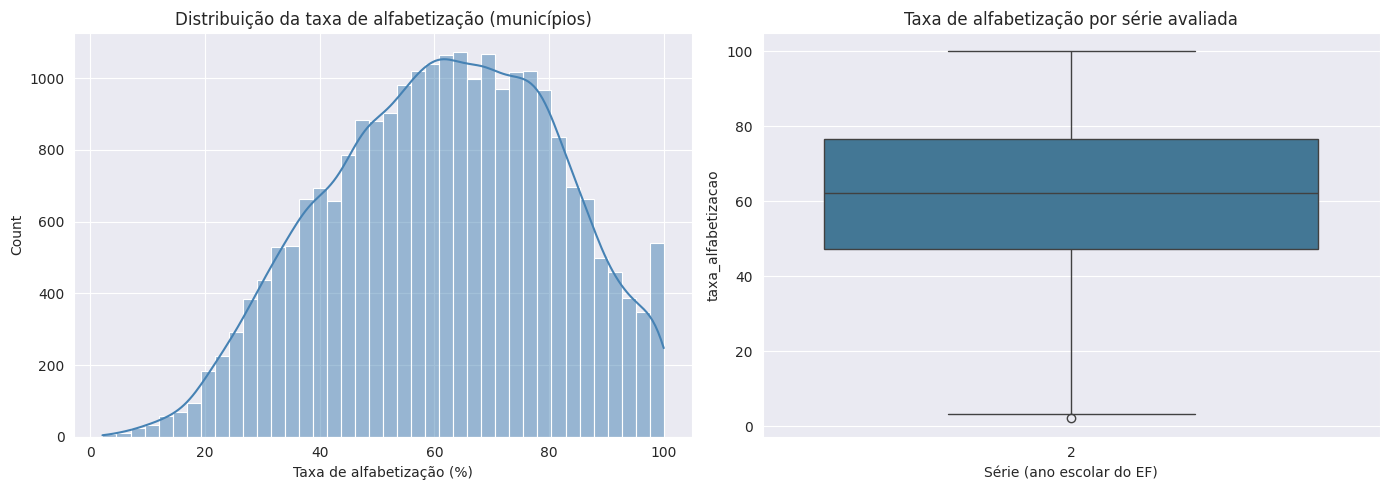

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ind_mun['taxa_alfabetizacao'].dropna(), bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição da taxa de alfabetização (municípios)')
axes[0].set_xlabel('Taxa de alfabetização (%)')

sns.boxplot(data=ind_mun, x='serie', y='taxa_alfabetizacao', ax=axes[1], palette='mako')
axes[1].set_title('Taxa de alfabetização por série avaliada')
axes[1].set_xlabel('Série (ano escolar do EF)')

plt.tight_layout()
plt.show()

## 7. Classificação de risco

Aplicamos a mesma régua usada pela flag `risco_alfabetizacao` do consumer de streaming (`streaming_glue.py`): **CRÍTICO** < 60%, **ATENÇÃO** < 75%, **NORMAL** ≥ 75%. Isso conecta a análise exploratória à semântica operacional da pipeline.

risco
CRITICO    5006
NORMAL     3026
ATENCAO    2864
Name: count, dtype: int64


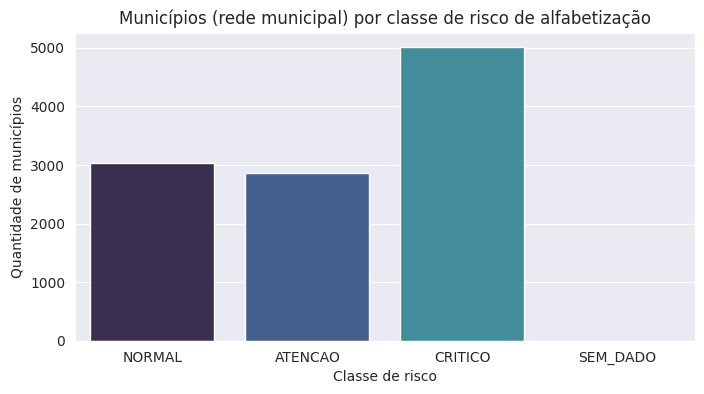

In [11]:
def classificar_risco(taxa):
    """Classifica o município segundo a régua operacional da pipeline."""
    if pd.isna(taxa):
        return 'SEM_DADO'
    if taxa < 60:
        return 'CRITICO'
    if taxa < 75:
        return 'ATENCAO'
    return 'NORMAL'

# Foco na rede municipal (código 3) — mesma seleção da visão Gold
mun_rede3 = ind_mun[ind_mun['rede'] == '3'].copy()
mun_rede3['risco'] = mun_rede3['taxa_alfabetizacao'].apply(classificar_risco)

dist_risco = mun_rede3['risco'].value_counts()
print(dist_risco)

plt.figure(figsize=(8, 4))
sns.countplot(data=mun_rede3, x='risco',
              order=['NORMAL', 'ATENCAO', 'CRITICO', 'SEM_DADO'], palette='mako')
plt.title('Municípios (rede municipal) por classe de risco de alfabetização')
plt.xlabel('Classe de risco')
plt.ylabel('Quantidade de municípios')
plt.show()

## 8. Análise por UF

Taxa média municipal por UF (rede municipal), ordenada da maior para a menor — o mesmo recorte da visão `evolucao_temporal` da Gold.

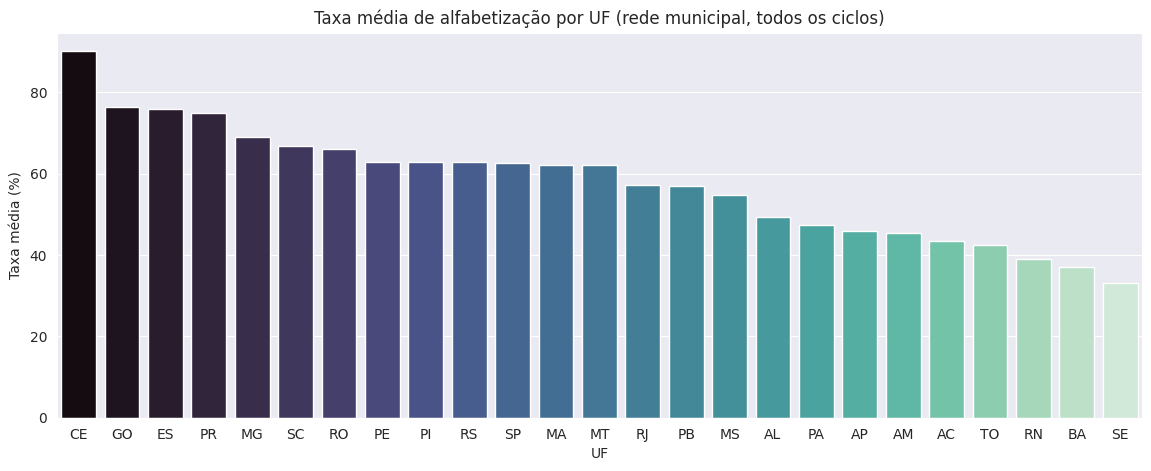

,cod_uf,taxa_alfabetizacao,sigla_uf
8,23,90.14,CE
24,52,76.44,GO
16,32,75.85,ES
19,41,74.95,PR
15,31,68.96,MG
20,42,66.87,SC
0,11,66.13,RO
11,26,62.96,PE
7,22,62.88,PI
21,43,62.76,RS


In [12]:
taxa_uf = (mun_rede3
           .assign(cod_uf=mun_rede3['id_municipio'].str[:2])
           .groupby('cod_uf', as_index=False)['taxa_alfabetizacao'].mean()
           .round(2))

IBGE_UF = {'11':'RO','12':'AC','13':'AM','14':'RR','15':'PA','16':'AP','17':'TO',
           '21':'MA','22':'PI','23':'CE','24':'RN','25':'PB','26':'PE','27':'AL','28':'SE','29':'BA',
           '31':'MG','32':'ES','33':'RJ','35':'SP','41':'PR','42':'SC','43':'RS',
           '50':'MS','51':'MT','52':'GO','53':'DF'}
taxa_uf['sigla_uf'] = taxa_uf['cod_uf'].map(IBGE_UF)
taxa_uf = taxa_uf.sort_values('taxa_alfabetizacao', ascending=False)

plt.figure(figsize=(14, 5))
paleta = sns.color_palette('mako', len(taxa_uf))
sns.barplot(data=taxa_uf, x='sigla_uf', y='taxa_alfabetizacao', palette=paleta)
plt.title('Taxa média de alfabetização por UF (rede municipal, todos os ciclos)')
plt.xlabel('UF')
plt.ylabel('Taxa média (%)')
plt.show()

taxa_uf.head(10)

## 9. Evolução entre ciclos avaliativos

Comparamos a taxa por UF entre os anos disponíveis (rede municipal, série 2 — o recorte com cobertura completa nos dois ciclos; a rede "total" só está disponível para 2024). Essa comparação **só é possível porque o histórico completo é preservado** — daí a exigência de partições por ano em todas as camadas.

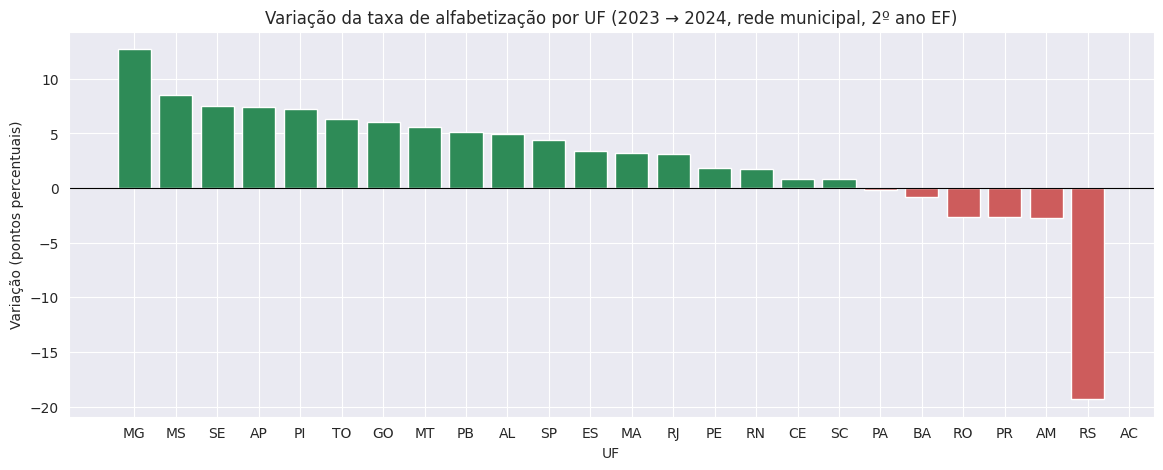

ano,2023,2024,variacao_pp
sigla_uf,,,
MG,58.74,71.45,12.71
MS,47.53,56.02,8.49
SE,30.57,38.05,7.48
AP,41.87,49.28,7.41
PI,52.50,59.76,7.26
TO,43.72,50.07,6.35
GO,66.72,72.73,6.01
MT,55.43,61.03,5.60
PB,50.92,56.01,5.09


In [13]:
evolucao = (ind_uf[(ind_uf['rede'] == '3') & (ind_uf['serie'] == 2)]
            .pivot_table(index='sigla_uf', columns='ano', values='taxa_alfabetizacao'))
anos_disp = sorted([c for c in evolucao.columns])
if len(anos_disp) >= 2:
    a0, a1 = anos_disp[0], anos_disp[-1]
    evolucao['variacao_pp'] = (evolucao[a1] - evolucao[a0]).round(2)
    evolucao = evolucao.sort_values('variacao_pp', ascending=False)

    plt.figure(figsize=(14, 5))
    cores = ['seagreen' if v >= 0 else 'indianred' for v in evolucao['variacao_pp']]
    plt.bar(evolucao.index, evolucao['variacao_pp'], color=cores)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(f'Variação da taxa de alfabetização por UF ({a0} → {a1}, rede municipal, 2º ano EF)')
    plt.xlabel('UF')
    plt.ylabel('Variação (pontos percentuais)')
    plt.show()

evolucao.head(10)

## 10. Resultados vs metas pactuadas

As metas estaduais valem para o período 2024–2030 e são pactuadas **por UF** (chave territorial). Comparamos o resultado mais recente de cada UF com a meta de 2025 — antecipando a lógica da visão `comparacao_metas_nacionais` da Gold.

Ano de referência do resultado: 2024
status
NAO_ATINGIU    22
ATINGIU         3
Name: count, dtype: int64


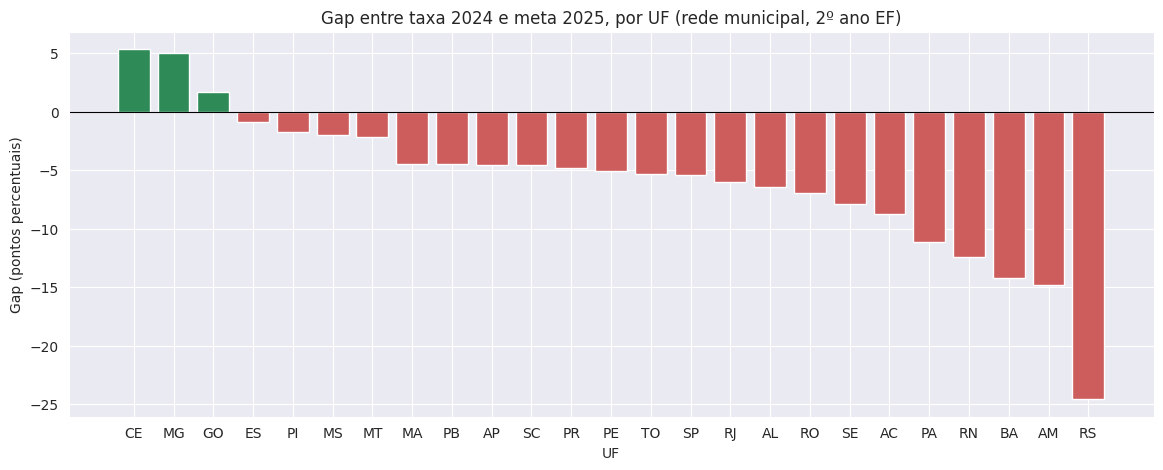

In [14]:
# Resultado mais recente por UF (rede municipal, série 2 — cobertura completa)
ano_recente = ind_uf['ano'].max()
resultado = (ind_uf[(ind_uf['rede'] == '3') & (ind_uf['serie'] == 2) & (ind_uf['ano'] == ano_recente)]
             [['sigla_uf', 'taxa_alfabetizacao']])

# Metas por UF: uma linha por UF (chave territorial)
metas = meta_uf.drop_duplicates('sigla_uf')[['sigla_uf', 'meta_alfabetizacao_2025', 'meta_alfabetizacao_2030']]

vs_meta = resultado.merge(metas, on='sigla_uf', how='left')
vs_meta['gap_2025'] = (vs_meta['taxa_alfabetizacao'] - vs_meta['meta_alfabetizacao_2025']).round(2)
vs_meta['status'] = np.where(vs_meta['gap_2025'] >= 0, 'ATINGIU', 'NAO_ATINGIU')
vs_meta = vs_meta.sort_values('gap_2025', ascending=False)

print(f"Ano de referência do resultado: {ano_recente}")
print(vs_meta['status'].value_counts())

plt.figure(figsize=(14, 5))
cores = ['seagreen' if v >= 0 else 'indianred' for v in vs_meta['gap_2025']]
plt.bar(vs_meta['sigla_uf'], vs_meta['gap_2025'], color=cores)
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f'Gap entre taxa {ano_recente} e meta 2025, por UF (rede municipal, 2º ano EF)')
plt.xlabel('UF')
plt.ylabel('Gap (pontos percentuais)')
plt.show()

> **Nuance de integração encontrada:** a coluna `ano` das bases de metas registra o **ano de pactuação**, não o ciclo avaliativo — um join cego por `ano` entre resultado e meta produziria nulos. A integração correta é por **chave territorial** (`sigla_uf` / `id_municipio`), com as metas anuais lidas das colunas `meta_alfabetizacao_YYYY`. Esse achado da EDA orienta os joins da camada Gold.

## 11. Municípios vs metas municipais

In [15]:
metas_mun = meta_mun.drop_duplicates('id_municipio')[['id_municipio', 'meta_alfabetizacao_2025']]
mun_recente = mun_rede3[mun_rede3['ano'] == ano_recente]

vs_meta_mun = mun_recente.merge(metas_mun, on='id_municipio', how='left')
vs_meta_mun['atingiu_2025'] = vs_meta_mun['taxa_alfabetizacao'] >= vs_meta_mun['meta_alfabetizacao_2025']

com_meta = vs_meta_mun['meta_alfabetizacao_2025'].notna().sum()
atingiu  = int(vs_meta_mun['atingiu_2025'].sum())
print(f'Municípios (rede municipal, {ano_recente}) com meta pactuada: {com_meta}')
print(f'Já no nível da meta 2025: {atingiu} ({atingiu/com_meta*100:.1f}%)')
print(f'Abaixo da meta 2025    : {com_meta - atingiu} ({(com_meta-atingiu)/com_meta*100:.1f}%)')

Municípios (rede municipal, 2024) com meta pactuada: 5352
Já no nível da meta 2025: 2322 (43.4%)
Abaixo da meta 2025    : 3030 (56.6%)


## 12. Conclusões

**Sobre o fenômeno:**
1. A distribuição da taxa de alfabetização entre municípios é ampla — a desigualdade territorial é o fato central que as visões Gold (`ranking_municipios`, `evolucao_temporal`) quantificam.
2. Parte relevante dos municípios ainda está abaixo da meta pactuada para 2025, e as classes CRÍTICO/ATENÇÃO concentram os casos que exigem intervenção prioritária — exatamente o público-alvo da flag `risco_alfabetizacao` do streaming.
3. A comparação entre ciclos mostra evolução heterogênea entre UFs, reforçando a necessidade de **série histórica completa** para avaliar política pública.

**Sobre a engenharia (decisões fundamentadas por esta EDA):**
1. **Particionamento por `ano`** em Bronze, Silver e Gold: a base cresce um ciclo por ano e as análises são sempre comparativas entre anos — partition pruning reduz bytes escaneados e custo (FinOps).
2. **Tipagem explícita** das chaves (`id_municipio` string de 7 dígitos): inferência numérica corromperia o código IBGE.
3. **Regras DQ com quarentena**: nulos existem e se concentram em métricas complementares; chaves e métrica principal nulas devem reprovar o registro, sem descartá-lo (auditoria).
4. **Joins por chave territorial** entre resultados e metas (não por `ano`), com metas anuais em colunas — nuance identificada na seção 10.